### Reloading training data

In [1]:
%%time
# Loads the data AND reproduces the exact splits the harness trained on, so figures
# here reconcile with results/*.json. The npz `tr_mask`/`te_mask` are NOT that split:
# they are the QDate month split (Feb-Jun / Jul-Aug), which differs from the
# label-observation split by the boundary jobs -- the population the leakage argument
# is about. Use d.train()/d.test() rather than those masks.
import numpy as np

from eval.dataset import load_experiment

EXPERIMENT = "e2"          # e1 | e2 | e3 -- picks the matrix and label time
SPLIT = "temporal"         # temporal | random

d = load_experiment(EXPERIMENT)

Xmatch, Xsub = d.Xmatch, d.Xsub
failed, hw, wait_sv = d.failed, d.hw, d.wait_sv
XMATCH_COLS, XSUB_COLS = d.xmatch_cols, d.xsub_cols
NCAT_MATCH, NCAT_SUB = d.ncat_match, d.ncat_sub
cards, n_base = d.schema["cards"], d.schema["n_base"]
X = Xmatch[:, :n_base]

# Index arrays, not boolean masks -- these are what the harness uses.
tr_idx, te_idx = d.train(SPLIT), d.test(SPLIT)

# Test indices for every split, captured here so the figure cells never have to reach
# back into `d`: the notebook namespace is shared, and any later cell that binds the
# name -- a loop variable is enough -- leaves the figures reading whatever it left.
TEST_IDX = {s: d.test(s) for s in ("temporal", "random")}

print(f"Loaded Xmatch {Xmatch.shape} and Xsub {Xsub.shape}")
print(f"{EXPERIMENT}/{SPLIT}: train {len(tr_idx):,} | test {len(te_idx):,}")

[temporal split] train 48,542,883 | test 15,545,475 | 8,936 boundary jobs moved to test | 0 rows fell back to queue time
[shared-oot split] pool 57,714,713 | temporal train 48,542,883 / test 9,171,830 (through 2025-08-01) | random same sizes, 15.9% of its training rows from the protocol period
[shared-oot split] out-of-time test 6,373,645 rows from 2025-08-01, scored by both arms, trained on by neither
<ExperimentData e2 @ 2025-07-01  random: train 48,542,883 / test 9,171,830  temporal: train 48,542,883 / test 9,171,830  oot: 6,373,645>
Loaded Xmatch (64088358, 44) and Xsub (64088358, 27)
e2/temporal: train 48,542,883 | test 9,171,830
CPU times: user 51.3 s, sys: 1min 6s, total: 1min 57s
Wall time: 1min 47s


### Reading models

In [3]:
import glob
import os

from eval.paths import all_model_dirs

# Saved as models/<experiment>/<model>/<lib>_<kind>_<split>.<ext>, so select on the
# filename parts rather than on a fixed directory. A multi-seed run leaves the last
# seed's model; per-seed numbers live in the results JSON, not here.
SPLIT = "temporal"

model_paths = []
# `mdir`, not `d`: a for-loop variable leaks into the notebook's shared namespace,
# and `d` is the ExperimentData object bound in the load cell.
for mdir in all_model_dirs():
    if not os.path.exists(mdir):
        continue
    for ext in ["*.pt", "*.zip", "*.joblib", "*.pkl", "*.model", "*.bin", "*.txt", "*.json"]:
        for path in glob.glob(os.path.join(mdir, ext)):
            if f"_reg_{SPLIT}" in os.path.basename(path) and f"{os.sep}e2{os.sep}" in path:
                print("appending model path:", path)
                model_paths.append(path)

print(f"Found {len(model_paths)} candidate model file(s).")

appending model path: /mnt/scratch/fast0/amaustin/models/e2/catboost/catboost_reg_temporal.txt
appending model path: /mnt/scratch/fast0/amaustin/models/e2/ft/ft_reg_temporal.pt
appending model path: /mnt/scratch/fast0/amaustin/models/e2/hierarchical/hierarchical_reg_temporal.joblib
appending model path: /mnt/scratch/fast0/amaustin/models/e2/lightgbm/lightgbm_reg_temporal.txt
appending model path: /mnt/scratch/fast0/amaustin/models/e2/saint/saint_reg_temporal.pt
appending model path: /mnt/scratch/fast0/amaustin/models/e2/tabnet/tabnet_reg_temporal.zip
appending model path: /mnt/scratch/fast0/amaustin/models/e2/tsmixer/tsmixer_reg_temporal.pt
appending model path: /mnt/scratch/fast0/amaustin/models/e2/xgboost/xgboost_reg_temporal.json
Found 8 candidate model file(s).


### Re-evaluating models (skip if needed)

In [ ]:
%%time
import os
import json
import warnings
import importlib
import eval.helper
importlib.reload(eval.helper)
from eval.helper import evaluate_wait_models

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

X_test = Xsub[te_idx]
y_test_raw = wait_sv[te_idx]
campaign_ids_test = X_test[:, XSUB_COLS.index("CampaignId")]
campaign_group_cols_test = {"Group": X_test[:, XSUB_COLS.index("Group")]}

df_results, results_by_model, campaign_by_model = evaluate_wait_models(
    model_paths=model_paths,
    X_test=X_test,
    y_test_raw=y_test_raw,
    is_log_pred=True,
    campaign_ids=campaign_ids_test,
    campaign_group_cols=campaign_group_cols_test,
)

wait_json_path = "output/wait_time_results.json"
data = {}
if os.path.exists(wait_json_path) and os.path.getsize(wait_json_path) > 0:
    with open(wait_json_path) as f:
        data = json.load(f)
for raw_key, mm in results_by_model.items():
    data.setdefault(raw_key, {})["temporal"] = mm
with open(wait_json_path, "w") as f:
    json.dump(data, f, indent=2)

campaign_json_path = "output/wait_time_campaign_results.json"
with open(campaign_json_path, "w") as f:
    json.dump(campaign_by_model, f, indent=2)

print(
    f"Appended {wait_json_path}; saved per-campaign breakdown for "
    f"{len(campaign_by_model)} models to {campaign_json_path}. "
    f"Figures below read df_results/results_by_model/campaign_by_model "
    f"directly from this cell, not from disk."
)

### Performance by model and wait-time bin

In [2]:
import json
import numpy as np
import pandas as pd
import importlib
import eval.helper
importlib.reload(eval.helper)
from eval.helper import (MODEL_DISPLAY_NAMES, PREFERRED_MODEL_ORDER,
                         WAIT_REGIMES)

RESULTS_PATH = "results/wait_time_results.json"
SPLIT = "temporal"
CONTRAST_SPLIT = "random"
# A model with r2_log < 0 does worse than predicting the mean wait for every
# job, so its per-bin errors describe a model no one would deploy. Flip to
# False to keep them in the figures for diagnostic purposes.
DROP_NEGATIVE_R2 = True

# results/wait_time_results.json is APPEND-ONLY, so it still holds entries from runs
# that predate the current feature matrices and the fit-derived error bins. Rather
# than naming the models that have been rerun -- a list that goes stale the moment
# another finishes -- select on whether an entry carries the new regime keys. An old
# entry has only the legacy <10m / 10m-2h / >2h bins and is skipped automatically.
REGIME_KEYS = [f"mae_{name}" for name, _, _ in WAIT_REGIMES]
REQUIRE_CURRENT_BINS = True

# Entries are keyed "<split>" for a default-seed run and "<split>__seed<n>" for a
# multi-seed one, so a model may carry both from different runs. The file has no
# timestamps, so recency has to be inferred from the key shape: the current protocol
# always runs --seeds 0,1,2, which means a PLAIN key can only have come from an older
# single-seed run. Prefer the seeded entries.
#
# This preference used to run the other way, from a round where the trees were rerun
# at the default seed AFTER their seeded entries. That is no longer true and the rule
# had gone stale in the worst way: it was showing the trees' pre-holdout-fix numbers
# (xgboost 74 s) next to the neural models' post-fix numbers (seeded, 102 s), i.e.
# comparing two different training protocols inside one figure.
PREFER_SEEDED = True

with open(RESULTS_PATH) as f:
    _raw = json.load(f)


def _seed_keys(splits, split):
    return [k for k in splits
            if k == split or k.startswith(f"{split}__seed")]


def build_split_frame(split, verbose=True):
    """Mean (and SD) across seeds for every model carrying the current bins on `split`.

    Returns a frame indexed by display name in PREFERRED_MODEL_ORDER. `n_seeds` records
    how many runs went into each row; `<key>__sd` is the sample SD across them, NaN for
    a single-seed row so the figures draw no bar rather than a zero-length one.
    """
    rows, stale, partial, mixed = [], [], [], []
    for key, splits in _raw.items():
        name = MODEL_DISPLAY_NAMES.get(key, key)
        cand = _seed_keys(splits, split)
        current = [k for k in cand
                   if not REQUIRE_CURRENT_BINS or all(m in splits[k] for m in REGIME_KEYS)]
        if not current:
            if cand:
                stale.append(name)
            continue
        seeded = [k for k in current if k != split]
        if PREFER_SEEDED and seeded and split in current:
            mixed.append(f"{name} (kept {len(seeded)} seeded, ignored default-seed entry)")
            current = seeded
        elif not PREFER_SEEDED and split in current and len(current) > 1:
            mixed.append(f"{name} (kept default-seed run, ignored "
                         f"{len(current) - 1} seeded entr"
                         f"{'y' if len(current) == 2 else 'ies'})")
            current = [split]
        nums = [k for k in splits[current[0]]
                if isinstance(splits[current[0]][k], (int, float))
                and not isinstance(splits[current[0]][k], bool)]
        agg = {}
        for k in nums:
            vals = [splits[c][k] for c in current if k in splits[c]]
            agg[k] = float(np.mean(vals))
            agg[f"{k}__sd"] = float(np.std(vals, ddof=1)) if len(vals) > 1 else float("nan")
        agg["n_seeds"] = len(current)
        rows.append({"model": name, **agg})
        if len(current) not in (1, 3, 5):
            partial.append(f"{name} ({len(current)} seeds)")

    df = pd.DataFrame(rows)
    if df.empty:
        raise RuntimeError(f"no entries with the current bins for split '{split}' -- "
                           f"rerun the harness, or set REQUIRE_CURRENT_BINS = False")

    dropped = df.loc[df["r2_log"] < 0, "model"].tolist()
    if DROP_NEGATIVE_R2 and dropped:
        df = df[df["r2_log"] >= 0]

    # Ordered by PREFERRED_MODEL_ORDER (trees first, then neural), matching the README
    # and run_sweep.sh, so every figure and table can be read position by position.
    # Anything not in that list sorts last, alphabetically.
    order = [MODEL_DISPLAY_NAMES.get(k, k) for k in PREFERRED_MODEL_ORDER]
    rank = {n: i for i, n in enumerate(dict.fromkeys(order))}
    df = (df.assign(_rank=df["model"].map(lambda m: rank.get(m, len(rank))))
            .sort_values(["_rank", "model"])
            .drop(columns="_rank")
            .set_index("model"))

    if verbose:
        print(f"[{split}] {len(df)} model(s)")
        print("  seeds per model: "
              + ", ".join(f"{m}={int(n)}" for m, n in zip(df.index, df["n_seeds"])))
        if stale:
            print(f"  skipped (only pre-regeneration entries): {', '.join(sorted(set(stale)))}")
        if partial:
            print(f"  INCOMPLETE seed sets: {', '.join(sorted(set(partial)))}")
        if mixed:
            print(f"  mixed run types: {'; '.join(sorted(set(mixed)))}")
        if dropped:
            kept = "excluded" if DROP_NEGATIVE_R2 else "kept"
            print(f"  r2_log < 0 ({kept}): {', '.join(dropped)}")
    return df


print(f"{RESULTS_PATH}")
df_wait = build_split_frame(SPLIT)
# The contrast line is reindexed onto the temporal model list so both lines share an
# x-axis. A model the temporal split dropped (r2_log < 0) stays dropped in both; a
# model with no usable random entry becomes NaN and simply breaks its line.
df_rand = build_split_frame(CONTRAST_SPLIT).reindex(df_wait.index)
_missing = df_rand.index[df_rand["r2_log"].isna()].tolist()
if _missing:
    print(f"  [{CONTRAST_SPLIT}] no usable entry for: {', '.join(_missing)}")

_cols = ["r2_log", "median_ae_s", "mae_raw_s", "within2x", "n_seeds"]
display(pd.concat({SPLIT: df_wait[_cols], CONTRAST_SPLIT: df_rand[_cols]},
                  axis=1).round(3))


results/wait_time_results.json
[temporal] 4 model(s)
  seeds per model: XGBoost=3, LightGBM=3, CatBoost=3, TSMixer=3
  mixed run types: CatBoost (kept 3 seeded, ignored default-seed entry); LightGBM (kept 3 seeded, ignored default-seed entry); XGBoost (kept 3 seeded, ignored default-seed entry)
  r2_log < 0 (excluded): SAINT, MLP, FT-Transformer, Hierarchical, TabNet
[random] 9 model(s)
  seeds per model: XGBoost=3, LightGBM=3, CatBoost=3, MLP=3, TabNet=3, SAINT=3, FT-Transformer=3, TSMixer=3, Hierarchical=3
  mixed run types: CatBoost (kept 3 seeded, ignored default-seed entry); LightGBM (kept 3 seeded, ignored default-seed entry); XGBoost (kept 3 seeded, ignored default-seed entry)


temporal                                         random              \
           r2_log median_ae_s  mae_raw_s within2x n_seeds r2_log median_ae_s   
model                                                                          
XGBoost     0.238    1904.262  10935.183    0.277       3  0.830     638.024   
LightGBM    0.227    1894.797  10867.559    0.280       3  0.826     647.989   
CatBoost    0.219    1891.269  10566.553    0.282       3  0.748     819.331   
TSMixer     0.065    2669.882  12238.519    0.239       3  0.651    1114.223   

                                      
          mae_raw_s within2x n_seeds  
model                                 
XGBoost    5439.358    0.626       3  
LightGBM   5552.808    0.619       3  
CatBoost   7425.508    0.519       3  
TSMixer   10096.589    0.441       3

### Summary across protocols (random vs temporal)

output/e2_protocol_summary.pdf


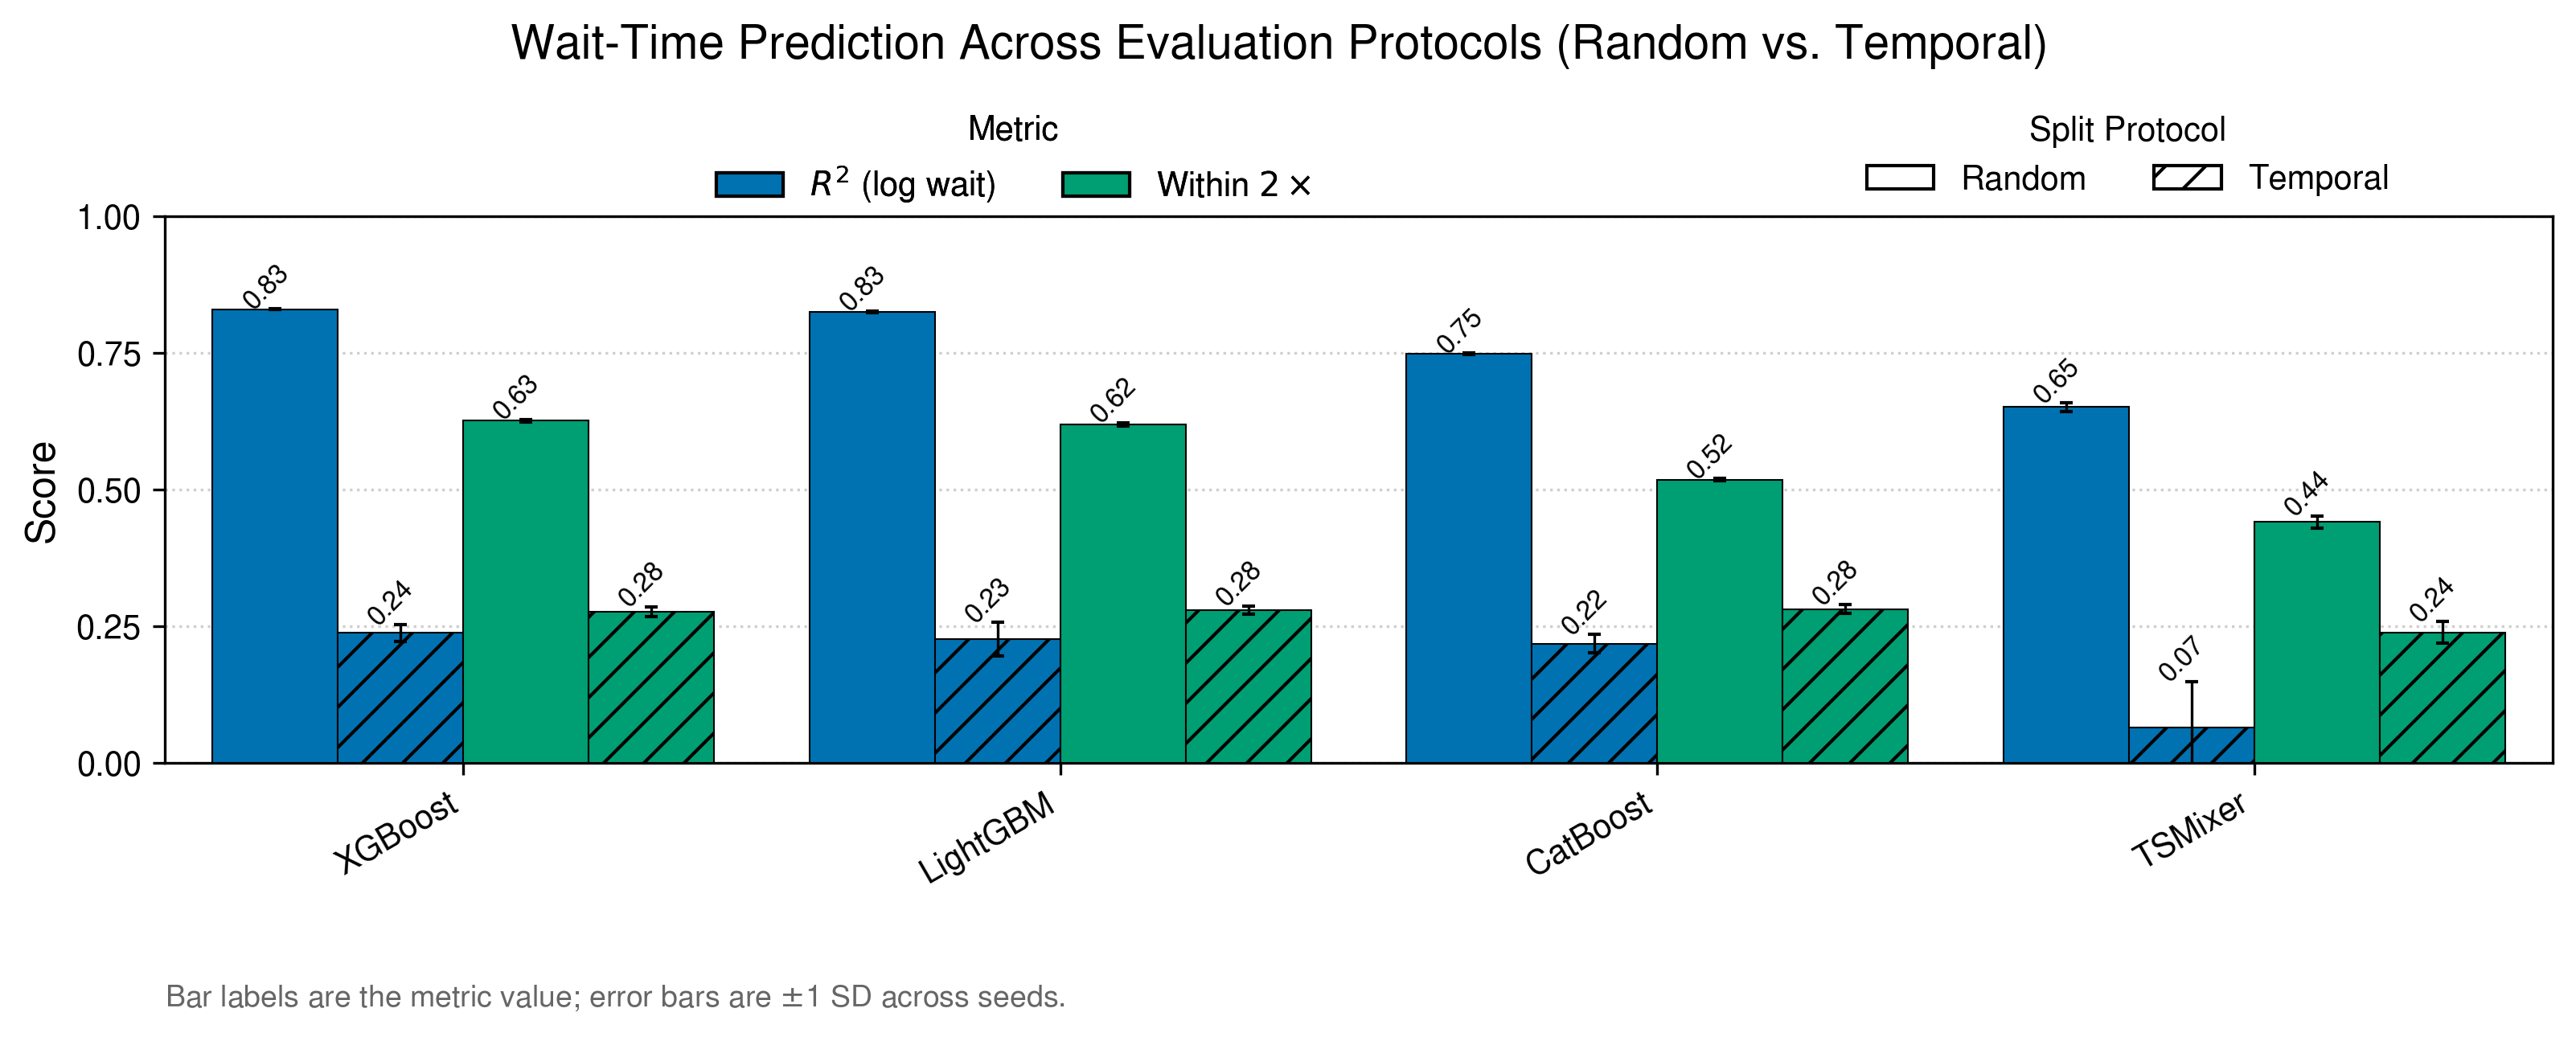


model            split      median_ae_s    mae_raw_s  mean/med
XGBoost          random           638.0      5,439.4     8.53x
LightGBM         random           648.0      5,552.8     8.57x
CatBoost         random           819.3      7,425.5     9.06x
TSMixer          random         1,114.2     10,096.6     9.06x
XGBoost          temporal       1,904.3     10,935.2     5.74x
LightGBM         temporal       1,894.8     10,867.6     5.74x
CatBoost         temporal       1,891.3     10,566.6     5.59x
TSMixer          temporal       2,669.9     12,238.5     4.58x


In [3]:
# Figure: E2 bounded metrics grouped by model, laid out like
# output/protocol_ablation_summary.pdf -- COLOUR is the metric, TEXTURE is the split
# protocol (solid random, hatched temporal), legends across the top, axes in a box.
#
# Only the bounded scores are plotted. Median AE is in seconds and cannot share a
# 0-1 axis without becoming a different quantity; it is printed as a table below
# instead, alongside the mean, since the two differ by 5-9x on this target.
#
# The number above each bar is that bar's metric value -- the same quantity the y
# axis shows, printed so exact values can be read without measuring against the
# gridlines. Error bars are +/- 1 SD across seeds.
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from vis.style import apply_style, COLORS, COMPONENTS, save_fig
apply_style()

SCORE_METRICS = [
    ("r2_log",   "$R^2$ (log wait)", COLORS["primary"]),
    ("within2x", "Within $2\\times$",   COMPONENTS[0]),
]
HATCH = "//"
SPLIT_ORDER = [("random", None), ("temporal", HATCH)]
ANNOTATE = True

_frames = {"random": df_rand, "temporal": df_wait}
# Frames are indexed by DISPLAY name; PREFERRED_MODEL_ORDER holds lowercase library
# keys. Only models in both splits are drawn -- a lone bar would read as a protocol
# effect rather than a run that has not happened yet.
_order = list(dict.fromkeys(MODEL_DISPLAY_NAMES.get(m.lower(), m)
                            for m in PREFERRED_MODEL_ORDER))
_models = [m for m in _order if all(m in f.index for f in _frames.values())]
_missing = sorted(set().union(*(set(f.index) for f in _frames.values())) - set(_models))
if _missing:
    print(f"not in both splits, omitted: {', '.join(_missing)}")

x = np.arange(len(_models))


def _series(frame, key):
    def _get(col):
        return np.array([frame.loc[m, col] if (m in frame.index and col in frame.columns)
                         else np.nan for m in _models], dtype=float)
    return _get(key), _get(key + "__sd")


fig, ax = plt.subplots(figsize=(11.0, 4.2), dpi=300)

n = len(SCORE_METRICS) * len(SPLIT_ORDER)
w = 0.84 / n
for i, (key, _lab, colr) in enumerate(SCORE_METRICS):
    for j, (split, hatch) in enumerate(SPLIT_ORDER):
        vals, sd = _series(_frames[split], key)
        off = (i * len(SPLIT_ORDER) + j - (n - 1) / 2) * w
        err = np.where(np.isfinite(sd), sd, 0.0)
        ax.bar(x + off, np.nan_to_num(vals), w, color=colr, hatch=hatch,
               edgecolor="black", linewidth=0.5,
               yerr=err, capsize=2.0, error_kw={"elinewidth": 0.8}, zorder=3)
        if ANNOTATE:
            for xi, v, e in zip(x + off, vals, err):
                if np.isfinite(v):
                    ax.annotate(f"{v:.2f}", (xi, v + e), textcoords="offset points",
                                xytext=(0, 4), ha="center", va="bottom",
                                rotation=45, rotation_mode="anchor",
                                fontsize=8, zorder=5)

ax.set_xticks(x)
ax.set_xlim(-0.5, len(_models) - 0.5)
ax.set_xticklabels(_models, rotation=30, ha="right")
ax.set_ylim(0, 1.0)
ax.set_yticks([0.0, 0.25, 0.50, 0.75, 1.00])
ax.set_ylabel("Score")
ax.grid(axis="y", linestyle=":", alpha=0.6)
ax.grid(axis="x", visible=False)
ax.set_axisbelow(True)
# Full box, as in the reference. The shared style drops the top and right spines for
# line charts; a boxed bar chart wants them back.
for _sp in ax.spines.values():
    _sp.set_visible(True)

_clipped = [(m, s) for s, f in _frames.items() for m in _models
            if m in f.index and "r2_log" in f.columns
            and np.isfinite(f.loc[m, "r2_log"]) and f.loc[m, "r2_log"] < 0]
if _clipped:
    print("r2_log < 0, clipped by the 0-1 axis: "
          + ", ".join(f"{m} ({s})" for m, s in _clipped))

_metric_handles = [Patch(facecolor=c, edgecolor="black", label=l)
                   for _k, l, c in SCORE_METRICS]
_split_handles = [
    Patch(facecolor="white", edgecolor="black", label="Random"),
    Patch(facecolor="white", edgecolor="black", hatch=HATCH, label="Temporal"),
]
fig.subplots_adjust(top=0.80, bottom=0.26, left=0.08, right=0.98)
_l1 = fig.legend(handles=_metric_handles, title="Metric", loc="upper center",
                 bbox_to_anchor=(0.40, 0.93), ncol=len(_metric_handles),
                 frameon=False, title_fontsize=10)
fig.legend(handles=_split_handles, title="Split Protocol", loc="upper center",
           bbox_to_anchor=(0.82, 0.93), ncol=2, frameon=False, title_fontsize=10)
fig.add_artist(_l1)

fig.suptitle("Wait-Time Prediction Across Evaluation Protocols "
             "(Random vs. Temporal)", fontsize=14, y=0.99)
fig.text(0.08, 0.02, "Bar labels are the metric value; error bars are "
                     "$\\pm$1 SD across seeds.",
         fontsize=9, color=COLORS["neutral"])
print(save_fig(fig, "e2_protocol_summary"))
plt.show()

# median_ae_s and mae_raw_s are the SAME per-job absolute errors in raw seconds,
# summarised differently: median vs mean (eval/helper.py, reg_metrics). On a
# right-skewed target the gap is the tail's contribution.
print(f"\n{'model':16s} {'split':9s} {'median_ae_s':>12s} {'mae_raw_s':>12s} {'mean/med':>9s}")
for split, frame in _frames.items():
    for m in _models:
        if m not in frame.index:
            continue
        med = frame.loc[m, "median_ae_s"] if "median_ae_s" in frame.columns else np.nan
        mean = frame.loc[m, "mae_raw_s"] if "mae_raw_s" in frame.columns else np.nan
        if np.isfinite(med) and np.isfinite(mean):
            print(f"{m:16s} {split:9s} {med:>12,.1f} {mean:>12,.1f} {mean / med:>8.2f}x")


### New runs

Test samples: temporal 13,592,837 | random 13,698,873
Wait range: 1.0s to 1245639.0s | Global Median: 2088.0s (34.8m)


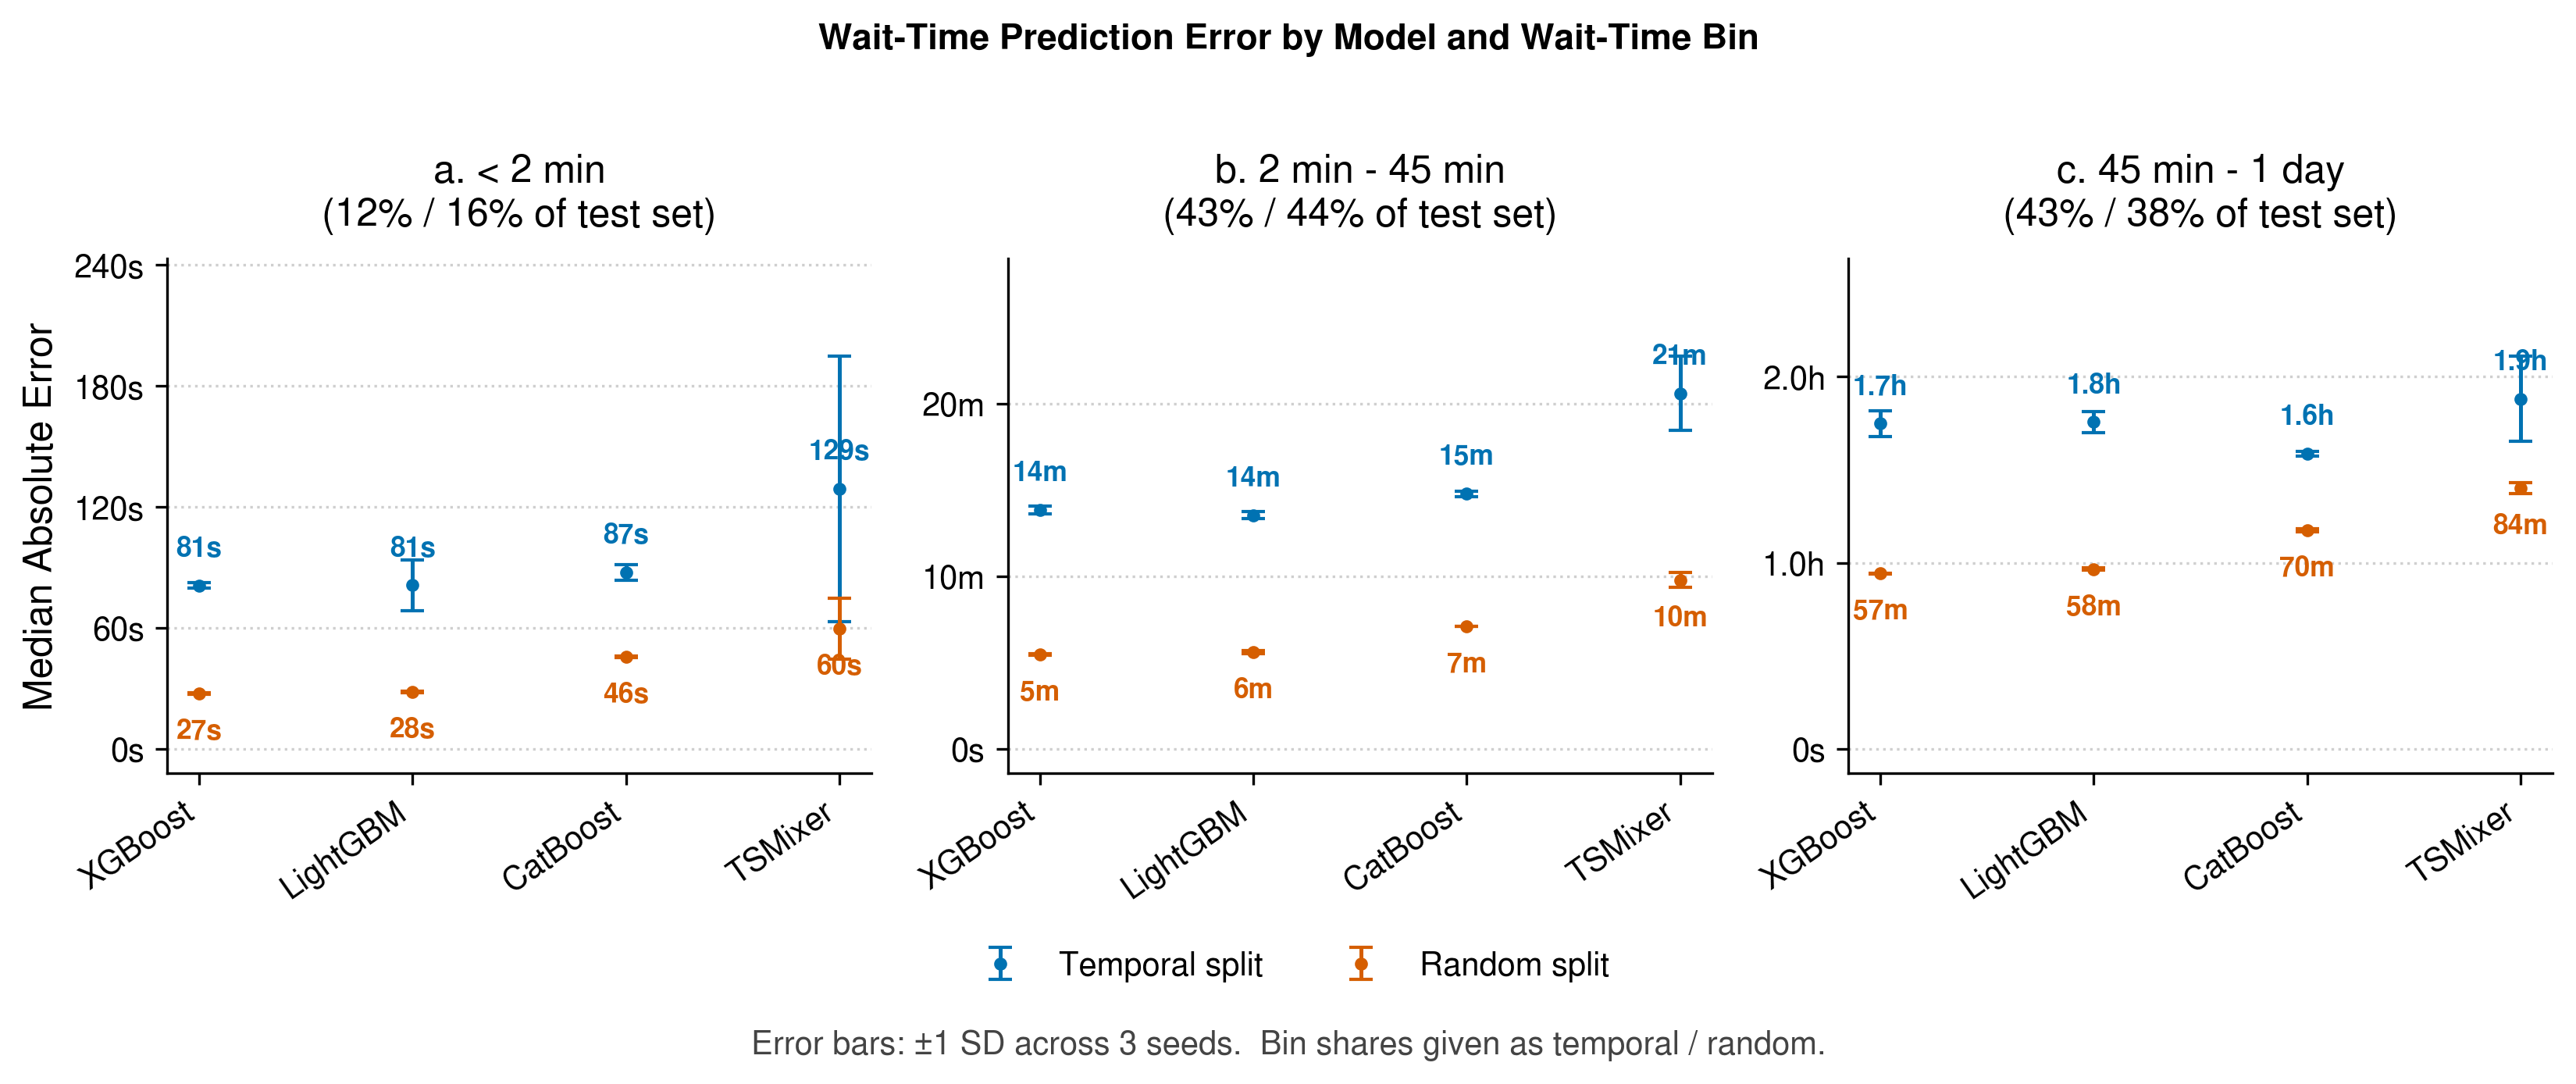

: 

In [ ]:
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

def _clean_wait(idx):
  """Test-set wait times in seconds, for the bin shares in the panel titles."""
  y = np.asarray(wait_sv[idx], dtype=np.float64).ravel()
  y = y[~np.isnan(y)]
  # Auto-detect log-transformed wait times (e.g., log1p seconds max out ~10-15)
  if y.max() < 25.0:
    y = np.expm1(y)
  # Auto-detect millisecond wait times (e.g., values in 1e6+)
  if np.median(y) > 100000:
    y = y / 1000.0
  return y


# Each split has its own test population: temporal is the last period, random is a
# uniform draw from all of it, so the same wait-time bin holds a different share of
# each. Both are computed and the titles show both when they disagree.
y_by_split = {SPLIT: _clean_wait(TEST_IDX[SPLIT]),
              CONTRAST_SPLIT: _clean_wait(TEST_IDX[CONTRAST_SPLIT])}
y_test_raw = y_by_split[SPLIT]
global_median_wait = float(np.median(y_test_raw))

print(f"Test samples: {SPLIT} {len(y_by_split[SPLIT]):,} | "
      f"{CONTRAST_SPLIT} {len(y_by_split[CONTRAST_SPLIT]):,}")
print(
    f"Wait range: {y_test_raw.min():.1f}s to {y_test_raw.max():.1f}s | Global"
    f" Median: {global_median_wait:.1f}s ({global_median_wait/60:.1f}m)"
)

# 2. Figure styling
plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": "Nimbus Sans",
        "font.size": 10,
        "axes.labelsize": 12,
        "axes.titlesize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
        "figure.titlesize": 12,
        "axes.grid": True,
        "grid.linestyle": ":",
        "grid.alpha": 0.6,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

COLORS = {
    "primary": "#0072B2",  # Temporal split
    "secondary": "#D55E00",  # Random split
    "baseline": "#222222",  # Baseline contrast line
}

# Error bins are the queueing REGIMES recovered by the lognormal-mixture fit on the
# FermiGrid wait distribution (data-analysis.ipynb, cell `fgmix`), not round numbers.
# The fitted components have medians 28 s / 779 s / 2.50 h, and one component
# overtakes the next at 106 s and 2,857 s; those crossovers round to 2 min and 45 min.
# Each bin is therefore a distinct queueing mechanism rather than an arbitrary cut:
#   inst -- matched into an already-idle pilot slot
#   turn -- waiting for an occupied slot to turn over
#   prov -- waiting for new pilot provisioning
#   park -- beyond the 1 d cap: NOT a fitted component, just the tail past the
#           fit population, kept separate so its ~20x larger errors do not swamp prov
BINS = [
    ("a. < 2 min", "median_ae_inst", "mae_inst", (0, 120), "s"),
    ("b. 2 min - 45 min", "median_ae_turn", "mae_turn", (120, 2700), None),
    ("c. 45 min - 1 day", "median_ae_prov", "mae_prov", (2700, 86400), None),
    ("d. > 1 day", "median_ae_park", "mae_park", (86400, None), None),
]


def _dur(s, min_unit=5400, unit=None):
  if s <= 0:
    return "0s"
  if unit == "s":          # forced, e.g. the sub-2-minute panel
    return f"{s:.0f}s"
  if s < 60:
    return f"{s:.0f}s"
  if s < min_unit:
    return f"{s / 60:.0f}m"
  if s < 86400:
    return f"{s / 3600:.1f}h"
  return f"{s / 86400:.1f}d"


def _nice_step(vmax):
  for step in (
      30,
      60,
      120,
      300,
      600,
      900,
      1800,
      3600,
      7200,
      10800,
      21600,
      43200,
  ):
    if vmax / step <= 5:
      return step
  return 86400


models = df_wait.index.tolist()
x = np.arange(len(models))

# The >1 d row is computed and stored by reg_metrics, but not plotted: it is the
# outlier tail beyond the mixture fit's population rather than a queueing regime,
# and its ~2-day errors would compress the three real regimes into the baseline.
PLOT_BINS = [b for b in BINS if b[2] != "mae_park"]

# Draw the "predict the global median for everything" reference line?
# It sits far above the model errors in the short bins, so it dominates
# the y-scale when shown.
SHOW_BASELINE = False


def _sd_descriptor(df):
  """What the error bars on this split's line actually represent.

  A bar is +/- 1 SD across seeds, so it exists only where more than one seed ran and
  has length only where the seeds diverged. Stating "+/- 1 SD across seeds" flatly
  would claim a measurement for every point, so the three cases stay distinct.
  """
  ns = (df["n_seeds"].values.astype(float) if "n_seeds" in df
        else np.ones(len(df)))
  ns = np.where(np.isfinite(ns), ns, 0.0)
  measured = ns > 1
  levels = sorted({int(n) for n in ns[measured]})
  n_present = int(np.isfinite(df["r2_log"].values).sum()) if "r2_log" in df else len(df)
  if not measured.any():
    return "single seed; spread not measured"
  if measured.sum() == n_present and len(levels) == 1:
    return f"±1 SD across {levels[0]} seeds"
  return (f"±1 SD across seeds; "
          f"{int(measured.sum())}/{n_present} models multi-seed")


# Temporal is always the upper line, so its labels go above and the random line's
# below: offsetting them the other way walks both label sets into the gap between
# the lines, which is exactly where they collide.
SERIES = [
    (SPLIT, df_wait, COLORS["primary"], "Temporal split", (0, 9)),
    (CONTRAST_SPLIT, df_rand, COLORS["secondary"], "Random split", (0, -14)),
]

# "median AE" lives on the y-axis and the error-bar meaning in the footnote, so the
# legend carries only the split name. The descriptor is repeated per entry only when
# the two splits genuinely differ -- e.g. one at 3 seeds and the other at 2.
_desc = {s: _sd_descriptor(df_s) for s, df_s, _, _, _ in SERIES}
_shared_desc = (_desc[SPLIT] if _desc[SPLIT] == _desc[CONTRAST_SPLIT] else None)
_labels = {s: stem if _shared_desc else f"{stem} ({_desc[s]})"
           for s, _, _, stem, _ in SERIES}

fig, axes = plt.subplots(1, len(PLOT_BINS), figsize=(3.7 * len(PLOT_BINS), 3.8),
                         dpi=300)

_split_shares = False       # set when any panel's two shares differ enough to show

for ax, (label, med_k, mean_k, (lo, hi), unit) in zip(axes, PLOT_BINS):
  _tops, _shares = [], {}

  for split_name, df_s, colr, stem, annot_off in SERIES:
    med = df_s[med_k].values.astype(float)
    _sd = (df_s[med_k + "__sd"].values.astype(float)
           if (med_k + "__sd") in df_s else np.full(len(x), np.nan))
    yerr = np.where(np.isfinite(_sd), _sd, 0.0)

    ys = y_by_split[split_name]
    msk = (ys >= lo) & (ys < hi) if hi is not None else (ys >= lo)
    _shares[split_name] = float(msk.mean()) if msk.size else 0.0

    # Median AE only. The wait distribution is heavy-tailed -- mean AE in these bins
    # runs 2-6x the median -- so the mean describes the tail rather than the typical
    # job, and plotting both invited reading the gap as a model property when it is a
    # property of the target.
    ax.errorbar(
        x,
        med,
        yerr=yerr,
        marker="o",
        linestyle="none",
        markersize=3,
        capsize=3.5,
        elinewidth=1.2,
        color=colr,
        label=_labels[split_name],
        zorder=4,
    )

    for i, m_val in enumerate(med):
      if not np.isfinite(m_val):
        continue
      ax.annotate(
          _dur(m_val, unit=unit),
          (x[i], m_val),
          textcoords="offset points",
          xytext=annot_off,
          ha="center",
          fontsize=8.5,
          color=colr,
          fontweight="bold",
      )

    _hi = med + yerr
    _tops.append(_hi[np.isfinite(_hi)])
    _tops.append(med[np.isfinite(med)])

  # Baseline error: median absolute error when predicting the global median.
  msk_b = ((y_test_raw >= lo) & (y_test_raw < hi) if hi is not None
           else (y_test_raw >= lo))
  base_ae = (float(np.median(np.abs(y_test_raw[msk_b] - global_median_wait)))
             if msk_b.any() else 0.0)
  
  _extra = [np.array([base_ae], dtype=float)] if SHOW_BASELINE else []
  _finite = np.concatenate(_tops + _extra) if (_tops or _extra) else np.array([])
  top = (float(_finite.max()) if _finite.size else 1.0) * 1.25
  if not np.isfinite(top) or top <= 0:
    top = 1.0
  ax.set_ylim(-0.05 * top, top)

  step = _nice_step(top)
  ax.yaxis.set_major_locator(mticker.MultipleLocator(step))
  ax.yaxis.set_major_formatter(
      mticker.FuncFormatter(lambda v, _, u=unit: _dur(v, 3600, unit=u))
  )

  # Two shares, named once in the footnote rather than on every panel.
  _a, _b = _shares[SPLIT], _shares[CONTRAST_SPLIT]
  if abs(_a - _b) < 0.01:
    _share_txt = f"{_a:.0%} of test set"
  else:
    _share_txt = f"{_a:.0%} / {_b:.0%} of test set"
    _split_shares = True
  ax.set_title(f"{label}\n({_share_txt})", pad=10)
  ax.set_xticks(x)
  ax.set_xticklabels(models, rotation=35, ha="right")
  ax.grid(axis="x", visible=False)
  ax.set_axisbelow(True)

axes[0].set_ylabel("Median Absolute Error")

# Collect legend handles uniquely across all subplots
handles_dict = {}
for ax in axes:
  h_list, l_list = ax.get_legend_handles_labels()
  for h, l in zip(h_list, l_list):
    if l not in handles_dict:
      handles_dict[l] = h

fig.legend(
    handles_dict.values(),
    handles_dict.keys(),
    loc="lower center",
    ncol=len(handles_dict),
    frameon=False,
    bbox_to_anchor=(0.5, -0.08),
)

_notes = []
if _shared_desc:
  _notes.append(f"Error bars: {_shared_desc}")
if _split_shares:
  _notes.append("Bin shares given as temporal / random")
if _notes:
  fig.text(0.5, -0.1, ".  ".join(_notes) + ".", ha="center", va="top",
           fontsize=10, color="#444444")

fig.suptitle(
    f"Wait-Time Prediction Error by Model and Wait-Time Bin",
    y=1.03,
    fontsize=11,
    fontweight="bold",
)

os.makedirs("output", exist_ok=True)
plt.tight_layout()
plt.savefig("output/wait_error_by_bin.pdf", bbox_inches="tight")
plt.show()